# Stochastic Computing Fundamentals and Baseline Multiplier

## Objective

The purpose of this notebook is to understand the fundamental principles of **stochastic computing (SC)** and implement a baseline stochastic multiplier for two unsigned 8-bit numbers.

The notebook investigates the following questions:

1. How can an 8-bit number be represented as a stochastic bitstream?
2. How is a stochastic bitstream decoded back into a numerical value?
3. Why can an AND gate perform multiplication in unipolar stochastic computing?
4. How does the multiplication estimate evolve as more stochastic bits are processed?
5. Why does a finite stochastic stream introduce approximation error?

---

## Target Computation Flow

The baseline stochastic multiplier follows this sequence:

$$
\text{8-bit Input}
\rightarrow
\text{Normalization}
\rightarrow
\text{Stochastic Number Generation}
\rightarrow
\text{Bitstream}
$$

The two stochastic streams are multiplied using an AND operation:

$$
Z_{SC} = A_{SC} \land B_{SC}
$$

The output stream is decoded using the fraction of ones:

$$
\hat{z}
=
\frac{\text{Number of Ones}}{\text{Stream Length}}
$$

Finally, the normalized result is converted back to the original 8-bit multiplication scale:

$$
\hat{P}
=
\hat{z}\times255^2
$$

The stochastic estimate is compared with the exact binary multiplication result:

$$
P_{\text{exact}} = A\times B
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed seed for reproducible experiments
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Representing an 8-bit Number in Stochastic Computing

In unipolar stochastic computing, a number is represented by the probability of observing a `1` in a bitstream.

For an unsigned 8-bit number:

$$
A \in [0,255]
$$

the normalized stochastic value is:

$$
a = \frac{A}{255}
$$

Therefore:

| 8-bit Value | Normalized Probability |
|---|---|
| $0$ | $0$ |
| $64$ | $\frac{64}{255}\approx0.251$ |
| $128$ | $\frac{128}{255}\approx0.502$ |
| $192$ | $\frac{192}{255}\approx0.753$ |
| $255$ | $1$ |

The probability $a$ represents the desired fraction of ones in the stochastic bitstream.

For example, if:

$$
a\approx0.5
$$

then approximately half of the bits in a sufficiently long bitstream should be `1`.

In [2]:
# Define the maximum value of an unsigned 8-bit number
MAX_VALUE = 255

# Example input value
A = 128

# Normalize A into the range [0, 1]
a = A / MAX_VALUE

print("Original 8-bit value A:", A)
print("Normalized stochastic value a:", a)
print(f"Target percentage of ones: {a * 100:.2f}%")

Original 8-bit value A: 128
Normalized stochastic value a: 0.5019607843137255
Target percentage of ones: 50.20%


# 2. Stochastic Number Generation

A **Stochastic Number Generator (SNG)** converts a numerical probability into a sequence of binary values.

For each clock cycle:

$$
P(X=1)=a
$$

where $a$ is the normalized input value.

In this software model, we generate a random number between $0$ and $1$.

The output rule is:

$$
X=
\begin{cases}
1, & r<a \\
0, & r\geq a
\end{cases}
$$

where $r$ is a uniformly distributed random number.

This Python implementation models the behavior of an SNG. Later, during RTL design, the random-number source can be implemented using hardware-oriented techniques such as an LFSR or deterministic sequence generator.

In [3]:
def generate_stochastic_stream(probability, length):
    """
    Generate a unipolar stochastic bitstream.

    Parameters
    ----------
    probability : float
        Probability of generating a 1.
        Must be between 0 and 1.

    length : int
        Number of bits in the stochastic stream.

    Returns
    -------
    numpy.ndarray
        Array containing binary values (0 or 1).
    """

    # Generate uniformly distributed random values
    random_values = np.random.rand(length)

    # Generate stochastic bits
    stream = (random_values < probability).astype(int)

    return stream

## Generating a Finite-Length Stochastic Bitstream

We now generate a stochastic bitstream representing the 8-bit value:

$$
A=128
$$

using a stream length:

$$
L=32
$$

The decoded value of the bitstream is obtained from:

$$
\hat{a}
=
\frac{\text{Number of Ones}}{L}
$$

Because the stream length is finite, the decoded probability may not exactly equal the target probability.

In [4]:
# Stream length
L = 32

# Generate the stochastic bitstream
stream_A = generate_stochastic_stream(a, L)

# Count the number of ones
ones_A = np.sum(stream_A)

# Decode the stochastic representation
decoded_a = ones_A / L

print("Input value A:", A)
print("Target probability:", a)
print("Stream length:", L)

print("\nGenerated stochastic bitstream:")
print(stream_A)

print("\nNumber of ones:", ones_A)
print("Decoded probability:", decoded_a)

print("\nRepresentation error:")
print(decoded_a - a)

Input value A: 128
Target probability: 0.5019607843137255
Stream length: 32

Generated stochastic bitstream:
[1 0 0 0 1 1 1 0 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1]

Number of ones: 18
Decoded probability: 0.5625

Representation error:
0.06053921568627452


# 3. Running Probability Estimate

A stochastic number is represented over time.

After each clock cycle $k$, the current probability estimate is:

$$
\hat{a}(k)
=
\frac{\text{Number of Ones observed up to cycle }k}{k}
$$

At the beginning of the stream, the estimate may fluctuate significantly because only a few samples have been observed.

As the number of processed bits increases, the estimate generally becomes more stable.

The following graph compares:

- the running stochastic estimate
- the target probability

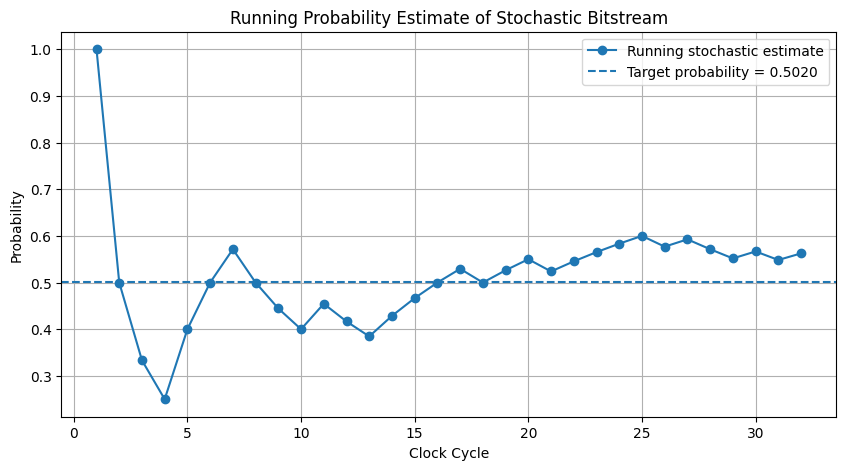

In [5]:
# Clock cycle numbers
cycles = np.arange(1, L + 1)

# Cumulative number of ones
cumulative_ones_A = np.cumsum(stream_A)

# Running probability estimate
running_probability_A = cumulative_ones_A / cycles

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    cycles,
    running_probability_A,
    marker='o',
    label='Running stochastic estimate'
)

plt.axhline(
    a,
    linestyle='--',
    label=f'Target probability = {a:.4f}'
)

plt.xlabel("Clock Cycle")
plt.ylabel("Probability")
plt.title("Running Probability Estimate of Stochastic Bitstream")

plt.legend()
plt.grid(True)

plt.show()

# 4. Stochastic Multiplication Using an AND Gate

We now introduce the second unsigned 8-bit input:

$$
B=192
$$

The normalized value is:

$$
b=\frac{B}{255}
$$

Two independent stochastic streams represent $a$ and $b$.

For independent streams:

$$
P(A_{SC}=1 \land B_{SC}=1)
=
P(A_{SC}=1)
\times
P(B_{SC}=1)
$$

Therefore:

$$
P(Z_{SC}=1)=a\times b
$$

This allows multiplication to be implemented using a single AND gate:

$$
Z_{SC}=A_{SC}\land B_{SC}
$$

This is the fundamental operation of a baseline unipolar stochastic multiplier.

In [6]:
# Define the second 8-bit input
B = 192

# Normalize B
b = B / MAX_VALUE

# Generate an independent stochastic bitstream for B
stream_B = generate_stochastic_stream(b, L)

# Perform stochastic multiplication using bitwise AND
stream_product = stream_A & stream_B

# Decode the normalized product
decoded_product_normalized = np.sum(stream_product) / L

# Convert the result back to the original multiplication scale
estimated_product = decoded_product_normalized * (MAX_VALUE ** 2)

# Exact binary multiplication
exact_product = A * B

# Calculate error
error = estimated_product - exact_product
absolute_error = abs(error)

print("Input A:", A)
print("Input B:", B)

print("\nNormalized A:", a)
print("Normalized B:", b)

print("\nExact product:", exact_product)
print("Stochastic estimated product:", estimated_product)

print("\nError:", error)
print("Absolute error:", absolute_error)

Input A: 128
Input B: 192

Normalized A: 0.5019607843137255
Normalized B: 0.7529411764705882

Exact product: 24576
Stochastic estimated product: 28448.4375

Error: 3872.4375
Absolute error: 3872.4375


# Why is the Output Multiplied by $255^2$?

The normalized inputs are:

$$
a=\frac{A}{255}
$$

and:

$$
b=\frac{B}{255}
$$

The AND operation estimates:

$$
z=a\times b
$$

Substituting the normalized values:

$$
z=
\frac{A}{255}
\times
\frac{B}{255}
$$

Therefore:

$$
z=
\frac{A\times B}{255^2}
$$

To recover the product in the original integer scale:

$$
\hat{P}
=
\hat{z}\times255^2
$$

The maximum possible product is:

$$
255\times255=65025
$$

which requires up to 16 bits to represent.

# 5. Running Stochastic Product Estimate

The stochastic multiplier produces its result over multiple clock cycles.

After each cycle $k$, the normalized product estimate is:

$$
\hat{z}(k)
=
\frac{\text{Number of Output Ones up to cycle }k}{k}
$$

The corresponding product estimate is:

$$
\hat{P}(k)
=
\hat{z}(k)\times255^2
$$

The following graph shows how the stochastic product estimate evolves over time and compares it with the exact binary product.

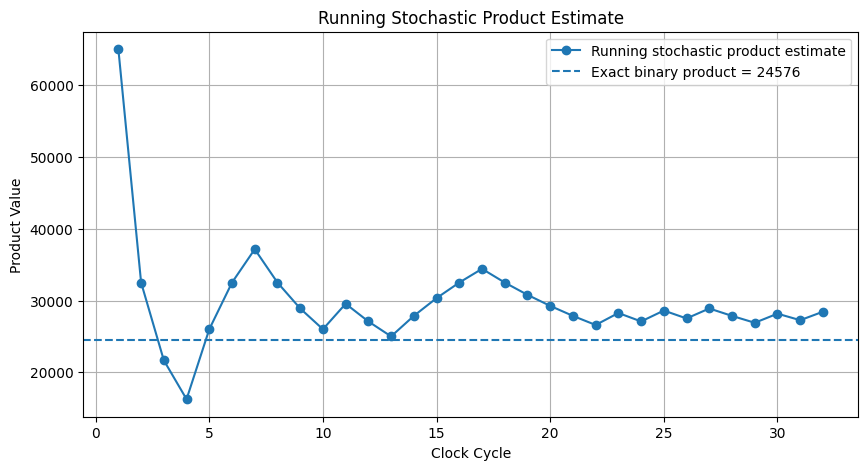

In [7]:
# Cumulative number of ones in the output stream
cumulative_product_ones = np.cumsum(stream_product)

# Running normalized product estimate
running_product_normalized = cumulative_product_ones / cycles

# Convert to original multiplication scale
running_product = running_product_normalized * (MAX_VALUE ** 2)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    cycles,
    running_product,
    marker='o',
    label='Running stochastic product estimate'
)

plt.axhline(
    exact_product,
    linestyle='--',
    label=f'Exact binary product = {exact_product}'
)

plt.xlabel("Clock Cycle")
plt.ylabel("Product Value")
plt.title("Running Stochastic Product Estimate")

plt.legend()
plt.grid(True)

plt.show()

# 6. Final Result Summary

The baseline stochastic multiplier can now be summarized using the following metrics:

- Exact binary product
- Stochastic estimated product
- Signed error
- Absolute error
- Stream length

The error is defined as:

$$
Error
=
\hat{P}_{SC}
-
P_{\text{exact}}
$$

The absolute error is:

$$
|Error|
=
\left|
\hat{P}_{SC}
-
P_{\text{exact}}
\right|
$$

In [8]:
print("=" * 55)
print("BASELINE STOCHASTIC MULTIPLIER RESULTS")
print("=" * 55)

print(f"Input A                  : {A}")
print(f"Input B                  : {B}")
print(f"Stream Length            : {L}")

print("-" * 55)

print(f"Exact Binary Product     : {exact_product:.2f}")
print(f"Stochastic Estimate      : {estimated_product:.2f}")

print("-" * 55)

print(f"Signed Error             : {error:.2f}")
print(f"Absolute Error           : {absolute_error:.2f}")

print("=" * 55)

BASELINE STOCHASTIC MULTIPLIER RESULTS
Input A                  : 128
Input B                  : 192
Stream Length            : 32
-------------------------------------------------------
Exact Binary Product     : 24576.00
Stochastic Estimate      : 28448.44
-------------------------------------------------------
Signed Error             : 3872.44
Absolute Error           : 3872.44


# 6. Effect of Stream Length on Multiplication Error

The previous experiment used only one stochastic stream length:

$$
L=32
$$

However, stochastic computing is probabilistic.

Therefore, a single experiment may produce a result that is better or worse than the average behavior.

To obtain a more reliable result, we perform a Monte Carlo simulation.

For each stream length:

$$
L \in \{8,16,32,64,128,256,512\}
$$

the stochastic multiplication experiment is repeated many times.

For every trial, new independent stochastic bitstreams are generated.

The absolute multiplication error is:

$$
E =
\left|
\hat{P}_{SC}
-
P_{\text{exact}}
\right|
$$

For each stream length, we calculate the average absolute error:

$$
MAE(L)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
\hat{P}_{SC,i}
-
P_{\text{exact}}
\right|
$$

where $N$ is the number of Monte Carlo trials.

This experiment allows us to investigate the fundamental tradeoff:

$$
\text{Stream Length}
\leftrightarrow
\text{Accuracy}
\leftrightarrow
\text{Latency}
$$

In [9]:
# Stream lengths to investigate
stream_lengths = [8, 16, 32, 64, 128, 256, 512]

# Number of independent Monte Carlo experiments
num_trials = 1000

# Store the average error for each stream length
mean_absolute_errors = []

# Store the standard deviation of the error
std_absolute_errors = []

# Exact binary multiplication result
exact_product = A * B

for L_test in stream_lengths:

    trial_errors = []

    for _ in range(num_trials):

        # Generate independent stochastic streams
        stream_A_test = generate_stochastic_stream(a, L_test)
        stream_B_test = generate_stochastic_stream(b, L_test)

        # Perform stochastic multiplication
        product_stream_test = stream_A_test & stream_B_test

        # Decode normalized product
        decoded_product = np.sum(product_stream_test) / L_test

        # Convert back to original multiplication scale
        estimated_product_test = decoded_product * (MAX_VALUE ** 2)

        # Calculate absolute error
        absolute_error_test = abs(
            estimated_product_test - exact_product
        )

        trial_errors.append(absolute_error_test)

    # Calculate statistics for this stream length
    mean_absolute_errors.append(np.mean(trial_errors))
    std_absolute_errors.append(np.std(trial_errors))


print("Monte Carlo Simulation Results")
print("=" * 60)

for L_test, mae, std in zip(
    stream_lengths,
    mean_absolute_errors,
    std_absolute_errors
):
    print(
        f"L = {L_test:3d} | "
        f"Mean Absolute Error = {mae:10.2f} | "
        f"Std = {std:10.2f}"
    )

Monte Carlo Simulation Results
L =   8 | Mean Absolute Error =    8763.64 | Std =    6842.99
L =  16 | Mean Absolute Error =    6047.23 | Std =    4958.37
L =  32 | Mean Absolute Error =    4545.57 | Std =    3492.62
L =  64 | Mean Absolute Error =    3219.83 | Std =    2332.02
L = 128 | Mean Absolute Error =    2283.93 | Std =    1683.05
L = 256 | Mean Absolute Error =    1537.89 | Std =    1183.93
L = 512 | Mean Absolute Error =    1120.85 | Std =     836.13


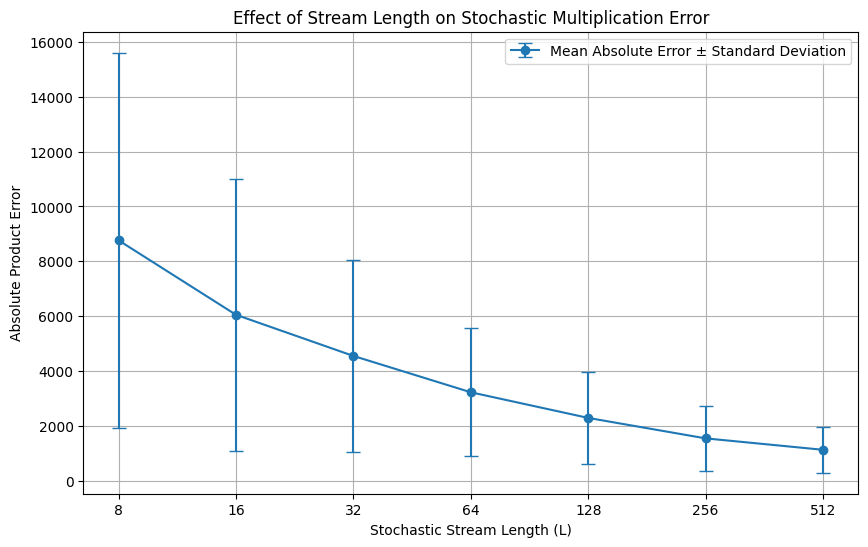

In [10]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    stream_lengths,
    mean_absolute_errors,
    yerr=std_absolute_errors,
    marker='o',
    capsize=5,
    label='Mean Absolute Error ± Standard Deviation'
)

plt.xlabel("Stochastic Stream Length (L)")
plt.ylabel("Absolute Product Error")
plt.title("Effect of Stream Length on Stochastic Multiplication Error")

plt.xscale("log", base=2)

plt.xticks(stream_lengths, stream_lengths)

plt.grid(True)
plt.legend()

plt.show()

## Comparison of the Target Stream Lengths

The project focuses particularly on short stochastic streams:

$$
L=16
\quad\text{and}\quad
L=32
$$

These stream lengths are important because shorter streams reduce computational latency but generally increase stochastic estimation error.

The following table compares the Monte Carlo results for the two target configurations.

In [11]:
# Find the positions of L = 16 and L = 32
index_16 = stream_lengths.index(16)
index_32 = stream_lengths.index(32)

print("=" * 55)
print("TARGET STREAM LENGTH COMPARISON")
print("=" * 55)

print(f"\nL = 16")
print(f"Mean Absolute Error : {mean_absolute_errors[index_16]:.2f}")
print(f"Standard Deviation  : {std_absolute_errors[index_16]:.2f}")

print("\n" + "-" * 55)

print(f"\nL = 32")
print(f"Mean Absolute Error : {mean_absolute_errors[index_32]:.2f}")
print(f"Standard Deviation  : {std_absolute_errors[index_32]:.2f}")

print("\n" + "=" * 55)

TARGET STREAM LENGTH COMPARISON

L = 16
Mean Absolute Error : 6047.23
Standard Deviation  : 4958.37

-------------------------------------------------------

L = 32
Mean Absolute Error : 4545.57
Standard Deviation  : 3492.62



# 7. Effect of Correlation Between Stochastic Input Vectors

The AND-based stochastic multiplier relies on an important assumption:

$$
P(A \land B)=P(A)P(B)
$$

This relationship is valid when the two stochastic input vectors are statistically independent.

However, if the positions of the `1`s in the two vectors are correlated, the probability of simultaneous `1`s changes.

For finite stochastic vectors, define:

$$
P_A=\frac{N_A}{V}
$$

$$
P_B=\frac{N_B}{V}
$$

where:

- $V$ is the stochastic vector length,
- $N_A$ is the number of `1`s in vector A,
- $N_B$ is the number of `1`s in vector B.

The joint probability is determined by the overlap:

$$
P_{11}=P(A=1,B=1)=\frac{N_{11}}{V}
$$

where $N_{11}$ is the number of positions where both vectors contain `1`.

Because the stochastic multiplier uses an AND gate:

$$
P_{\text{AND}}=P_{11}
$$

Therefore, changing the overlap between the two input vectors directly changes the multiplication result.

In this experiment, the marginal probabilities of the two vectors are kept fixed while their overlap is systematically changed.

This allows the effect of correlation on multiplication accuracy to be studied directly.

In [12]:
def number_of_ones(value, vector_length, max_value=255):
    """
    Convert an unsigned integer into the number of ones
    required in a stochastic vector.

    Parameters
    ----------
    value : int
        Unsigned input value.

    vector_length : int
        Length of the stochastic vector.

    max_value : int
        Maximum value of the input representation.
        For an 8-bit unsigned number, this is 255.

    Returns
    -------
    int
        Number of ones in the stochastic vector.
    """

    probability = value / max_value

    ones = int(round(probability * vector_length))

    ones = max(0, min(ones, vector_length))

    return ones

## Constructing Two Vectors with Controlled Correlation

To study correlation fairly, the probabilities of the two input vectors must remain fixed.

Therefore:

- The number of `1`s in vector A is fixed.
- The number of `1`s in vector B is fixed.
- Only the number of positions where both vectors contain `1` is changed.

Let:

$$
N_{11}
=
\text{number of overlapping ones}
$$

The feasible overlap range is:

$$
\max(0,N_A+N_B-V)
\leq
N_{11}
\leq
\min(N_A,N_B)
$$

The lower bound represents the maximum possible separation between the `1`s.

The upper bound represents the maximum possible overlap.

By changing $N_{11}$ within this valid range, we can generate negatively correlated, independent, and positively correlated stochastic vectors.

In [13]:
def generate_vectors_with_overlap(
    vector_length,
    ones_A,
    ones_B,
    overlap,
    rng=None
):
    """
    Generate two binary stochastic vectors with fixed
    numbers of ones and a controlled overlap.

    Parameters
    ----------
    vector_length : int
        Length of both stochastic vectors.

    ones_A : int
        Number of ones required in vector A.

    ones_B : int
        Number of ones required in vector B.

    overlap : int
        Number of positions where both A and B are one.

    rng : numpy random generator
        Optional random generator used to shuffle positions.

    Returns
    -------
    stream_A, stream_B
        Two binary numpy arrays.
    """

    if rng is None:
        rng = np.random.default_rng()

    # Check that the requested overlap is physically possible
    min_overlap = max(0, ones_A + ones_B - vector_length)
    max_overlap = min(ones_A, ones_B)

    if overlap < min_overlap or overlap > max_overlap:
        raise ValueError(
            f"Overlap must be between "
            f"{min_overlap} and {max_overlap}"
        )

    # Start with all-zero vectors
    stream_A = np.zeros(vector_length, dtype=int)
    stream_B = np.zeros(vector_length, dtype=int)

    # Randomly shuffle all available positions
    positions = rng.permutation(vector_length)

    # --------------------------------------------------
    # 1. Positions where both A and B are equal to 1
    # --------------------------------------------------

    common_positions = positions[:overlap]

    stream_A[common_positions] = 1
    stream_B[common_positions] = 1

    # --------------------------------------------------
    # 2. Positions containing only A = 1
    # --------------------------------------------------

    A_only_count = ones_A - overlap

    start_A = overlap
    end_A = start_A + A_only_count

    A_only_positions = positions[start_A:end_A]

    stream_A[A_only_positions] = 1

    # --------------------------------------------------
    # 3. Positions containing only B = 1
    # --------------------------------------------------

    B_only_count = ones_B - overlap

    start_B = end_A
    end_B = start_B + B_only_count

    B_only_positions = positions[start_B:end_B]

    stream_B[B_only_positions] = 1

    return stream_A, stream_B

## Measuring and Validating Correlation

The correlation experiment is validated using two complementary measurements.

### 1. Joint probability

The AND output probability is:

$$
P_{11}
=
\frac{N_{11}}{V}
$$

This is directly measured from the generated vectors.

### 2. Pearson correlation coefficient

For two binary random variables, the correlation coefficient is:

$$
\rho
=
\frac{
P_{11}-P_A P_B
}{
\sqrt{
P_A(1-P_A)P_B(1-P_B)
}
}
$$

The sign of $\rho$ indicates the relationship between the vectors:

- $\rho > 0$: positive correlation,
- $\rho \approx 0$: approximately independent behavior,
- $\rho < 0$: negative correlation.

The experiment is considered valid only if:

1. The generated vectors contain the intended number of `1`s.
2. The measured overlap equals the requested overlap.
3. The AND output probability equals the measured joint probability.
4. The measured correlation changes consistently as the overlap is changed.

In [14]:
def measure_stream_relationship(stream_A, stream_B):
    """
    Measure probabilities, overlap, AND output,
    and Pearson correlation for two binary streams.
    """

    vector_length = len(stream_A)

    # Individual probabilities
    p_A = np.mean(stream_A)
    p_B = np.mean(stream_B)

    # AND operation
    and_stream = stream_A & stream_B

    # Joint probability
    p_11 = np.mean(and_stream)

    # Covariance term
    covariance = p_11 - (p_A * p_B)

    # Pearson correlation denominator
    denominator = np.sqrt(
        p_A * (1 - p_A) *
        p_B * (1 - p_B)
    )

    # Pearson correlation
    if denominator == 0:
        correlation = np.nan
    else:
        correlation = covariance / denominator

    return {
        "vector_length": vector_length,
        "ones_A": int(np.sum(stream_A)),
        "ones_B": int(np.sum(stream_B)),
        "overlap": int(np.sum(and_stream)),
        "p_A": p_A,
        "p_B": p_B,
        "p_11": p_11,
        "correlation": correlation
    }

## Validation Example

Before performing the full correlation experiment, one generated pair of stochastic vectors is examined.

The following properties are checked:

- number of `1`s in vector A,
- number of `1`s in vector B,
- requested overlap,
- measured overlap,
- measured joint probability,
- measured correlation.

This verification ensures that the correlation experiment is based on controlled and physically valid stochastic vectors.

In [15]:
# Example parameters

V = 16

A_value = 128
B_value = 192

# Convert inputs into the required number of ones
ones_A = number_of_ones(A_value, V)
ones_B = number_of_ones(B_value, V)

# Feasible overlap range
min_overlap = max(0, ones_A + ones_B - V)
max_overlap = min(ones_A, ones_B)

# Choose one overlap value for validation
test_overlap = (min_overlap + max_overlap) // 2

# Reproducible random generator
rng = np.random.default_rng(42)

# Generate the two controlled vectors
stream_A_test, stream_B_test = generate_vectors_with_overlap(
    vector_length=V,
    ones_A=ones_A,
    ones_B=ones_B,
    overlap=test_overlap,
    rng=rng
)

# Measure the relationship
metrics = measure_stream_relationship(
    stream_A_test,
    stream_B_test
)

print("VALIDATION OF CONTROLLED CORRELATION")
print("=" * 55)

print(f"Vector Length           : {V}")
print(f"Input A                 : {A_value}")
print(f"Input B                 : {B_value}")

print()

print(f"Expected Ones in A      : {ones_A}")
print(f"Measured Ones in A      : {metrics['ones_A']}")

print()

print(f"Expected Ones in B      : {ones_B}")
print(f"Measured Ones in B      : {metrics['ones_B']}")

print()

print(f"Requested Overlap       : {test_overlap}")
print(f"Measured Overlap        : {metrics['overlap']}")

print()

print(f"P(A = 1)                : {metrics['p_A']:.4f}")
print(f"P(B = 1)                : {metrics['p_B']:.4f}")
print(f"P(A = 1, B = 1)         : {metrics['p_11']:.4f}")

print()

print(f"Pearson Correlation     : {metrics['correlation']:.4f}")

VALIDATION OF CONTROLLED CORRELATION
Vector Length           : 16
Input A                 : 128
Input B                 : 192

Expected Ones in A      : 8
Measured Ones in A      : 8

Expected Ones in B      : 12
Measured Ones in B      : 12

Requested Overlap       : 6
Measured Overlap        : 6

P(A = 1)                : 0.5000
P(B = 1)                : 0.7500
P(A = 1, B = 1)         : 0.3750

Pearson Correlation     : 0.0000


## Correlation Experiment for V = 16 and V = 32

The correlation experiment is performed for the two target stochastic vector lengths:

$$
V=16
$$

and:

$$
V=32
$$

For each vector length:

1. The number of `1`s in vector A is fixed.
2. The number of `1`s in vector B is fixed.
3. Every physically possible overlap value is tested.
4. The corresponding correlation is calculated.
5. The stochastic multiplication result is obtained using an AND operation.
6. The estimated product is compared with the exact binary product.

The exact binary multiplication is:

$$
P_{\text{exact}}=A\times B
$$

The stochastic product estimate is:

$$
\hat{P}_{SC}
=
P_{11}\times255^2
$$

The absolute product error is:

$$
E=
\left|
\hat{P}_{SC}
-
P_{\text{exact}}
\right|
$$

In [16]:
# ------------------------------------------------------
# CORRELATION EXPERIMENT
# ------------------------------------------------------

# Target vector lengths from the project specification
vector_lengths = [16, 32]

# Use the same inputs used in the earlier notebook
A_value = 128
B_value = 192

# Exact binary multiplication
exact_product = A_value * B_value

# Maximum unsigned 8-bit value
MAX_VALUE = 255

# Store all experimental results
correlation_results = []

# Reproducible generator
rng = np.random.default_rng(123)

for V in vector_lengths:

    # Determine the number of ones representing each input
    ones_A = number_of_ones(A_value, V, MAX_VALUE)
    ones_B = number_of_ones(B_value, V, MAX_VALUE)

    # Calculate all physically possible overlap values
    min_overlap = max(0, ones_A + ones_B - V)
    max_overlap = min(ones_A, ones_B)

    # Test every possible overlap
    for overlap in range(min_overlap, max_overlap + 1):

        # Generate vectors with controlled overlap
        stream_A, stream_B = generate_vectors_with_overlap(
            vector_length=V,
            ones_A=ones_A,
            ones_B=ones_B,
            overlap=overlap,
            rng=rng
        )

        # Measure correlation and probabilities
        metrics = measure_stream_relationship(
            stream_A,
            stream_B
        )

        # Perform stochastic multiplication
        product_stream = stream_A & stream_B

        # Decode normalized product
        normalized_product = np.mean(product_stream)

        # Convert to 8-bit x 8-bit product scale
        estimated_product = normalized_product * (MAX_VALUE ** 2)

        # Calculate absolute error
        absolute_error = abs(
            estimated_product - exact_product
        )

        # Independent expectation based on the
        # represented finite vectors
        represented_independent_product = (
            metrics["p_A"] * metrics["p_B"]
        )

        # Deviation caused by correlation
        correlation_deviation = abs(
            normalized_product -
            represented_independent_product
        )

        # Store results
        correlation_results.append({
            "V": V,
            "overlap": metrics["overlap"],
            "correlation": metrics["correlation"],
            "p_A": metrics["p_A"],
            "p_B": metrics["p_B"],
            "p_11": metrics["p_11"],
            "estimated_product": estimated_product,
            "absolute_error": absolute_error,
            "correlation_deviation": correlation_deviation
        })


print("CORRELATION EXPERIMENT COMPLETED")
print("=" * 60)
print(f"Input A          : {A_value}")
print(f"Input B          : {B_value}")
print(f"Exact Product    : {exact_product}")
print()
print(f"Vector Lengths   : {vector_lengths}")
print()
print(f"Number of Cases  : {len(correlation_results)}")

CORRELATION EXPERIMENT COMPLETED
Input A          : 128
Input B          : 192
Exact Product    : 24576

Vector Lengths   : [16, 32]

Number of Cases  : 14


## Experimental Results

The correlation experiment produces several measurements for every valid overlap condition.

The most important quantities are:

- Pearson correlation coefficient,
- joint probability $P_{11}$,
- stochastic product estimate,
- total product error,
- deviation from the independent multiplication relationship.

The correlation-induced deviation is:

$$
E_{\text{corr}}
=
\left|
P_{11}-P_A P_B
\right|
$$

This quantity directly measures how much the AND output differs from the ideal multiplication of the represented probabilities.

Therefore:

$$
E_{\text{corr}}=0
$$

indicates ideal independent multiplication behavior.

As correlation becomes positive or negative, the AND output moves away from the expected independent multiplication result.

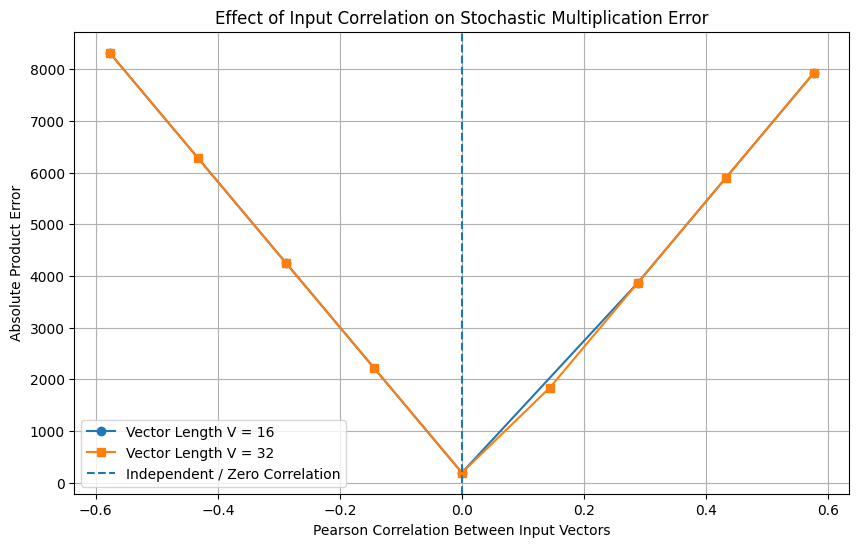

In [17]:
# Separate results for V = 16 and V = 32

results_V16 = [
    r for r in correlation_results
    if r["V"] == 16
]

results_V32 = [
    r for r in correlation_results
    if r["V"] == 32
]

# Sort by correlation value
results_V16 = sorted(
    results_V16,
    key=lambda x: x["correlation"]
)

results_V32 = sorted(
    results_V32,
    key=lambda x: x["correlation"]
)

# Extract values

corr_16 = [r["correlation"] for r in results_V16]
error_16 = [r["absolute_error"] for r in results_V16]

corr_32 = [r["correlation"] for r in results_V32]
error_32 = [r["absolute_error"] for r in results_V32]


plt.figure(figsize=(10, 6))

plt.plot(
    corr_16,
    error_16,
    marker="o",
    label="Vector Length V = 16"
)

plt.plot(
    corr_32,
    error_32,
    marker="s",
    label="Vector Length V = 32"
)

# Show the independent reference point
plt.axvline(
    0,
    linestyle="--",
    label="Independent / Zero Correlation"
)

plt.xlabel("Pearson Correlation Between Input Vectors")
plt.ylabel("Absolute Product Error")

plt.title(
    "Effect of Input Correlation on "
    "Stochastic Multiplication Error"
)

plt.grid(True)
plt.legend()

plt.show()

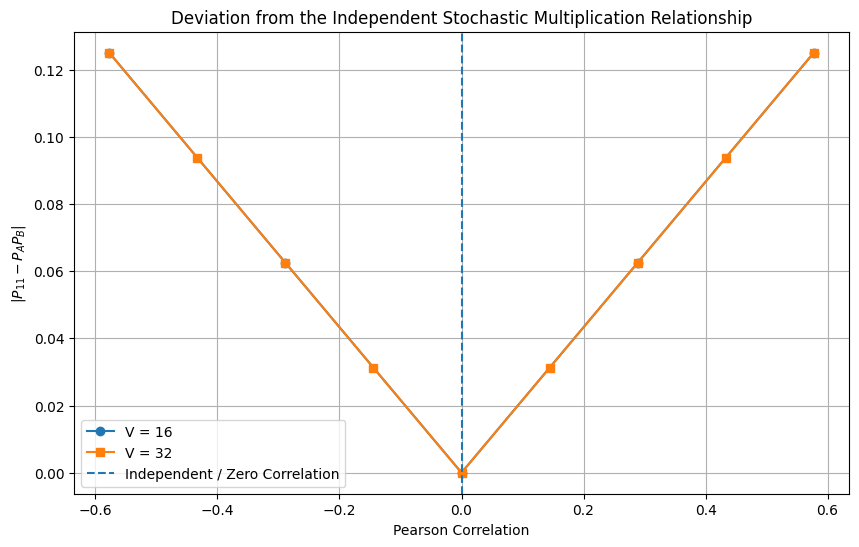

In [18]:
# Extract correlation deviation

corr_deviation_16 = [
    r["correlation_deviation"]
    for r in results_V16
]

corr_deviation_32 = [
    r["correlation_deviation"]
    for r in results_V32
]


plt.figure(figsize=(10, 6))

plt.plot(
    corr_16,
    corr_deviation_16,
    marker="o",
    label="V = 16"
)

plt.plot(
    corr_32,
    corr_deviation_32,
    marker="s",
    label="V = 32"
)

plt.axvline(
    0,
    linestyle="--",
    label="Independent / Zero Correlation"
)

plt.xlabel("Pearson Correlation")
plt.ylabel(r"$|P_{11} - P_A P_B|$")

plt.title(
    "Deviation from the Independent "
    "Stochastic Multiplication Relationship"
)

plt.grid(True)
plt.legend()

plt.show()

# 8. Discussion of the Correlation Results

The correlation experiment demonstrates that the accuracy of an AND-based stochastic multiplier depends not only on stochastic vector length but also on the relationship between the two input vectors.

For independent stochastic vectors:

$$
P(A \land B)
=
P(A)P(B)
$$

and the AND operation correctly implements stochastic multiplication.

However, when the input vectors are correlated:

$$
P(A \land B)
\neq
P(A)P(B)
$$

Positive correlation causes the `1`s in the two vectors to occur together more frequently.

Negative correlation causes the `1`s to avoid each other.

Both situations can produce a biased multiplication result.

The experiment also shows an important limitation of short stochastic vectors.

For finite vector lengths such as:

$$
V=16
$$

and:

$$
V=32
$$

only discrete overlap values are possible.

Therefore, both the stochastic probabilities and correlation values are quantized.

This makes the stochastic number generation method an important part of the final hardware architecture.

A good stochastic number generator must therefore provide:

1. accurate probability representation,
2. low unwanted correlation between multiplier inputs,
3. good accuracy with short vector lengths,
4. low hardware cost.

# 9. Final Conclusions

This notebook established the fundamental behavior of an unsigned stochastic multiplier for:

$$
8\text{-bit}
\times
8\text{-bit}
\rightarrow
16\text{-bit product}
$$

The main findings are summarized below.

## 1. Stochastic Representation

An unsigned binary number can be represented by the probability of obtaining `1` in a stochastic vector.

For an 8-bit input:

$$
P(X=1)
=
\frac{X}{255}
$$

A finite stochastic vector estimates this probability using the fraction of `1`s.

---

## 2. Stochastic Multiplication

For statistically independent input vectors:

$$
P(A \land B)
=
P(A)P(B)
$$

Therefore, multiplication can be implemented using a simple AND operation.

---

## 3. Effect of Vector Length

Increasing the stochastic vector length improves the statistical accuracy of the representation.

However, longer vectors require more clock cycles or more stochastic samples.

Therefore, stochastic computing involves a tradeoff:

$$
\text{Short Vector}
\Rightarrow
\text{Low Latency but Higher Error}
$$

$$
\text{Long Vector}
\Rightarrow
\text{Higher Accuracy but Higher Latency}
$$

The target vector lengths for this project are:

$$
V=16
$$

and:

$$
V=32
$$

which represent a short-vector stochastic computing design.

---

## 4. Effect of Correlation

The correlation experiment demonstrated that vector length is not the only factor affecting accuracy.

The relationship between the two input vectors is also important.

For independent vectors:

$$
P(A \land B)
\approx
P(A)P(B)
$$

However, positive or negative correlation can bias the AND output and increase multiplication error.

Therefore:

$$
\boxed{
\text{Stochastic Multiplier Accuracy}
=
f(
\text{Vector Length},
\text{Probability Representation},
\text{Correlation},
\text{SNG Design}
)
}
$$

---

## Next Step

The results of this notebook provide the baseline for the next stage of the project.

The next objective is to investigate different stochastic number generation architectures and determine how better stochastic vectors can improve accuracy at the short target vector lengths:

$$
V=16
\quad\text{and}\quad
V=32
$$

The following notebook will investigate:

- different stochastic number generators,
- independent and correlated generation methods,
- random versus deterministic sequences,
- LFSR-based generation,
- correlation-aware stochastic architectures,
- Monte Carlo accuracy analysis.

The ultimate goal is to use these results to develop an improved stochastic multiplier architecture suitable for RTL implementation and comparison with a conventional Booth multiplier.